<a href="https://colab.research.google.com/github/Hari-HK23/ML-Final-Lab-Group-05/blob/main/notebooks/Member2_DA_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DATA ANALYSIS

In [1]:
# ============================================
# 1. IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================
# 2. UPLOAD DATASET
# ============================================

uploaded = files.upload()

print("Uploaded file:")

for filename in uploaded.keys():
    print(filename)

Saving credit_card_fraud_raw_reduced_v3.csv to credit_card_fraud_raw_reduced_v3.csv
Uploaded file:
credit_card_fraud_raw_reduced_v3.csv


In [3]:
# ============================================
# 3. LOAD DATASET
# ============================================

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (88235, 15)


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2020-06-06 17:20:46,"Hoppe, Harris and Bedn",entertainment,12.850,Hawthorne,CA,33.914,-118.349,93193,"Editor, magazine features",1995-04-19,e730f1935a095deebe33994b12f17177,34.436,-118.229,0
1,2020-03-18 23:30:36,"Gottlieb, Considine and Schultz",shopping_net,2.120,Rock Springs,WY,41.606,-109.230,27971,Music therapist,1984-08-01,2cc6e6e3b0d409dee88aaee205e69b32,41.961,-109.673,0
2,2020-09-27 18:07:19,Bins-Tillman,entertainment,68.190,Helm,CA,36.499,-120.094,123,Early years teacher,1973-02-07,28bcc1336f61e190c8e72ce444e6d174,36.669,-120.405,0
3,2020-03-31 03:44:43,Heidenreich PLC,grocery_pos,53.990,Tekoa,WA,47.227,-117.082,895,Clothing/textile technologist,1999-05-31,21f54cfaef6f611a433cd8d683067c02,47.369,-117.165,0
4,2019-11-03 21:27:37,Predovic Inc,shopping_net,123.610,Lakeport,CA,39.047,-122.933,11256,Podiatrist,1972-10-18,7c96acccc4fb673c533b304e868452e5,39.406,-122.748,0


In [4]:
# ============================================
# 4. DATASET OVERVIEW
# ============================================

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 88235
Number of Columns: 15


In [5]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['trans_date_trans_time', 'merchant', 'category', 'amt', 'city', 'state', 'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'merch_lat', 'merch_long', 'is_fraud']


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
trans_date_trans_time     object
merchant                  object
category                  object
amt                      float64
city                      object
state                     object
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [7]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88235 entries, 0 to 88234
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   trans_date_trans_time  88235 non-null  object 
 1   merchant               88235 non-null  object 
 2   category               88235 non-null  object 
 3   amt                    88235 non-null  float64
 4   city                   88235 non-null  object 
 5   state                  88235 non-null  object 
 6   lat                    88235 non-null  float64
 7   long                   88235 non-null  float64
 8   city_pop               88235 non-null  int64  
 9   job                    88235 non-null  object 
 10  dob                    88235 non-null  object 
 11  trans_num              88235 non-null  object 
 12  merch_lat              88235 non-null  float64
 13  merch_long             88235 non-null  float64
 14  is_fraud               88235 non

In [8]:
# ============================================
# 5. DESCRIPTIVE STATISTICS
# ============================================

display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trans_date_trans_time,88235,88171,2020-04-06 13:34:00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
merchant,88235,693,Kilback LLC,299,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,88235,14,gas_transport,9085,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,88235.000,NaN,NaN,NaN,69.427,166.706,1.000,9.570,46.350,82.735,14407.250
city,88235,169,Phoenix,1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,88235,13,CA,21257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,88235.000,NaN,NaN,NaN,39.696,5.100,20.027,36.715,39.599,41.696,66.693
long,88235.000,NaN,NaN,NaN,-110.679,12.653,-165.672,-120.094,-111.099,-101.136,-89.629
city_pop,88235.000,NaN,NaN,NaN,107640.466,293573.317,46.000,493.000,1661.000,42384.000,2383912.000
job,88235,157,"Surveyor, minerals",1746,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ============================================
# 6. MISSING VALUE ANALYSIS
# ============================================

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': (missing_values / len(df)) * 100
})

display(missing_table)

,Missing Values,Missing Percentage
trans_date_trans_time,0,0.000
merchant,0,0.000
category,0,0.000
amt,0,0.000
city,0,0.000
state,0,0.000
lat,0,0.000
long,0,0.000
city_pop,0,0.000
job,0,0.000


In [10]:
# ============================================
# 7. DUPLICATE ANALYSIS
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [11]:
# ============================================
# 8. DATE/TIME PREPARATION
# ============================================

df['trans_date_trans_time'] = pd.to_datetime(
    df['trans_date_trans_time'],
    errors='coerce'
)

df['dob'] = pd.to_datetime(
    df['dob'],
    errors='coerce'
)

print("Date columns converted successfully.")

print("\nTransaction date range:")
print(df['trans_date_trans_time'].min())
print(df['trans_date_trans_time'].max())

Date columns converted successfully.

Transaction date range:
2019-01-01 00:00:44
2020-12-31 23:59:24


In [12]:
# ============================================
# 9. CREATE ANALYSIS FEATURES
# ============================================

# Transaction hour
df['hour'] = df['trans_date_trans_time'].dt.hour

# Day of week
# Monday = 0, Sunday = 6
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

# Month
df['month'] = df['trans_date_trans_time'].dt.month

# Age at transaction
df['age'] = (
    df['trans_date_trans_time'] - df['dob']
).dt.days / 365.25

print("Analysis features created successfully.")

display(
    df[
        [
            'trans_date_trans_time',
            'hour',
            'day_of_week',
            'month',
            'age'
        ]
    ].head()
)

Analysis features created successfully.


,trans_date_trans_time,hour,day_of_week,month,age
0,2020-06-06 17:20:46,17,5,6,25.133
1,2020-03-18 23:30:36,23,2,3,35.628
2,2020-09-27 18:07:19,18,6,9,47.636
3,2020-03-31 03:44:43,3,1,3,20.835
4,2019-11-03 21:27:37,21,6,11,47.042


In [13]:
# ============================================
# 10. TRANSACTION-MERCHANT DISTANCE
# ============================================

lat1 = np.radians(df['lat'])
lon1 = np.radians(df['long'])

lat2 = np.radians(df['merch_lat'])
lon2 = np.radians(df['merch_long'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2) ** 2
    + np.cos(lat1)
    * np.cos(lat2)
    * np.sin(dlon / 2) ** 2
)

df['distance_km'] = (
    6371 * 2 * np.arcsin(np.sqrt(a))
)

print("Distance feature created successfully.")

display(
    df[
        ['lat', 'long', 'merch_lat', 'merch_long', 'distance_km']
    ].head()
)

Distance feature created successfully.


,lat,long,merch_lat,merch_long,distance_km
0,33.914,-118.349,34.436,-118.229,59.092
1,41.606,-109.230,41.961,-109.673,53.924
2,36.499,-120.094,36.669,-120.405,33.631
3,47.227,-117.082,47.369,-117.165,16.995
4,39.047,-122.933,39.406,-122.748,42.952


In [14]:
# ============================================
# 11. NUMERICAL FEATURES FOR EDA
# ============================================

distribution_cols = [
    'amt',
    'city_pop',
    'age',
    'distance_km'
]

print("Numerical features selected for distribution analysis:")
print(distribution_cols)

Numerical features selected for distribution analysis:
['amt', 'city_pop', 'age', 'distance_km']


# 12. Class Distribution

The target variable `is_fraud` is analyzed to determine the proportion of
fraudulent and non-fraudulent transactions.

Class imbalance is important in fraud detection because a very small fraud
class can make accuracy misleading.


In [15]:
# ============================================
# 12. CLASS DISTRIBUTION
# ============================================

class_counts = df['is_fraud'].value_counts()

class_percent = (
    df['is_fraud']
    .value_counts(normalize=True) * 100
)

class_distribution = pd.DataFrame({
    'Transaction Count': class_counts,
    'Percentage': class_percent
})

display(class_distribution)

,Transaction Count,Percentage
is_fraud,,
0,88085,99.830
1,150,0.170


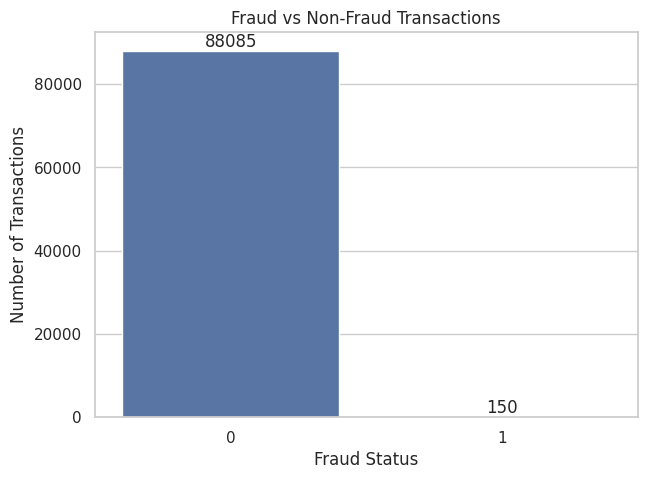

In [16]:
# ============================================
# 13. FRAUD VS NON-FRAUD PLOT
# ============================================

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='is_fraud'
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [18]:
# ============================================
# 15. CLASS DISTRIBUTION IMPACT
# ============================================

fraud_rate = df['is_fraud'].mean() * 100
non_fraud_rate = (
    1 - df['is_fraud'].mean()
) * 100

print(f"Non-Fraud Transactions: {non_fraud_rate:.3f}%")
print(f"Fraud Transactions: {fraud_rate:.3f}%")

print("\nFraud Count:", df['is_fraud'].sum())
print("Non-Fraud Count:", (df['is_fraud'] == 0).sum())

Non-Fraud Transactions: 99.830%
Fraud Transactions: 0.170%

Fraud Count: 150
Non-Fraud Count: 88085


### Interpretation

The dataset is highly imbalanced, with fraudulent transactions representing
only a small proportion of all transactions.

Therefore, accuracy alone may not provide a complete picture of fraud
detection performance. The ML team should pay attention to fraud-focused
evaluation metrics such as precision, recall and F1-score.

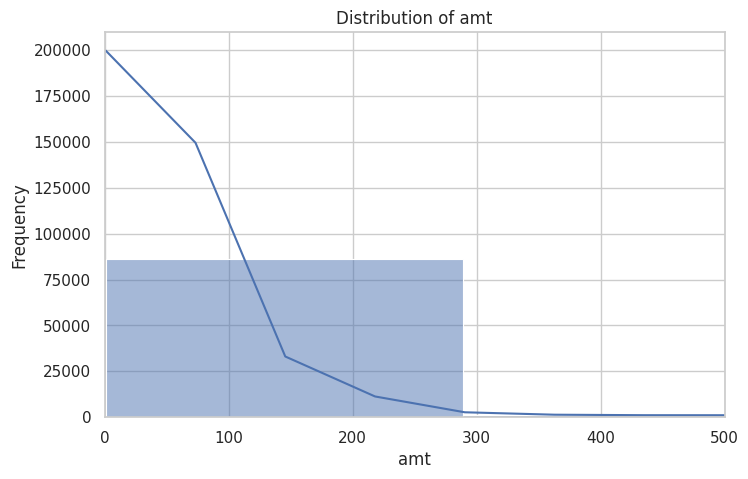

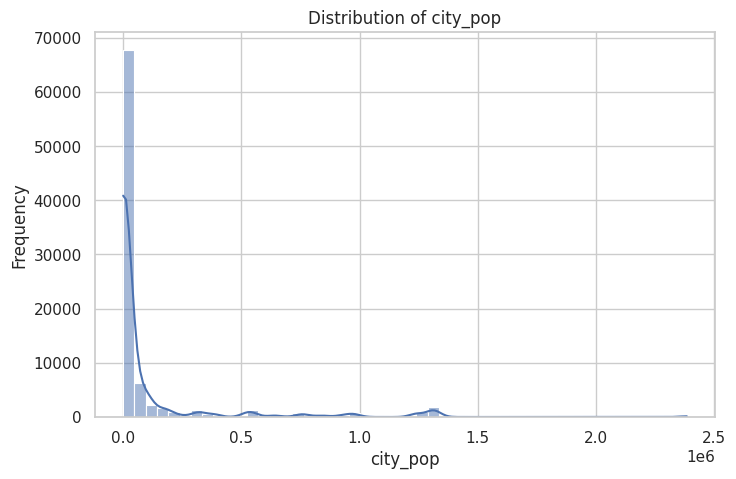

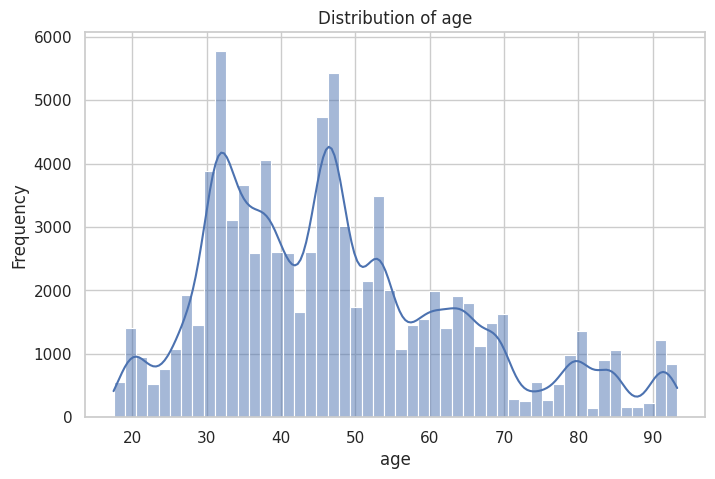

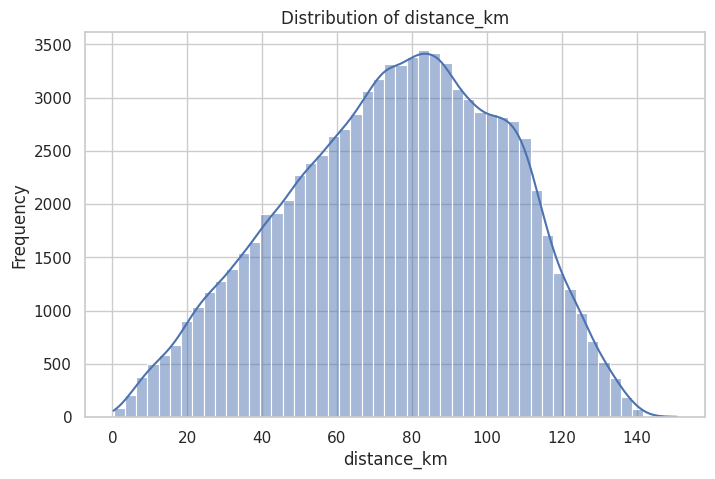

In [19]:
# ============================================
# 16. DISTRIBUTION ANALYSIS
# ============================================

for col in distribution_cols:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df[col],
        bins=50,
        kde=True
    )

    # Zoom transaction amount because it is highly right-skewed
    if col == 'amt':
        plt.xlim(0, 500)

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

In [20]:
# ============================================
# 17. SKEWNESS ANALYSIS
# ============================================

skewness = (
    df[distribution_cols]
    .skew()
    .sort_values(ascending=False)
)

skewness_table = pd.DataFrame({
    'Feature': skewness.index,
    'Skewness': skewness.values
})

display(skewness_table)

,Feature,Skewness
0,amt,32.739
1,city_pop,3.683
2,age,0.702
3,distance_km,-0.223


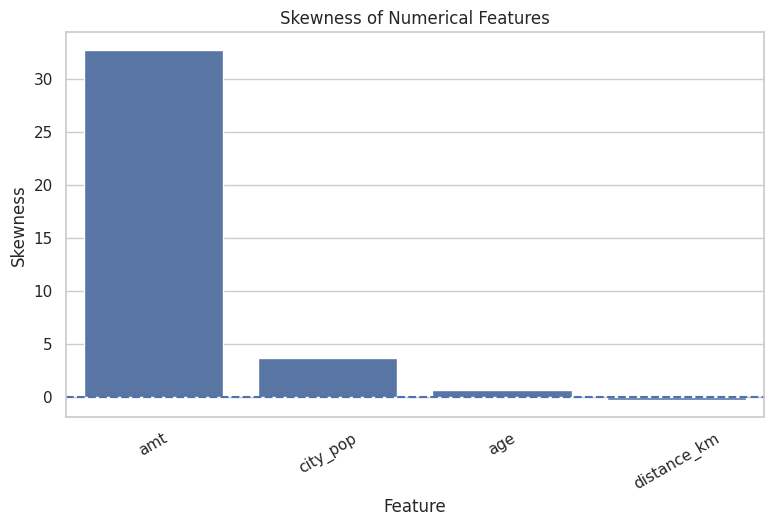

In [21]:
# ============================================
# 18. SKEWNESS PLOT
# ============================================

plt.figure(figsize=(9, 5))

sns.barplot(
    x=skewness.index,
    y=skewness.values
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Skewness of Numerical Features")
plt.xlabel("Feature")
plt.ylabel("Skewness")

plt.xticks(rotation=30)

plt.show()

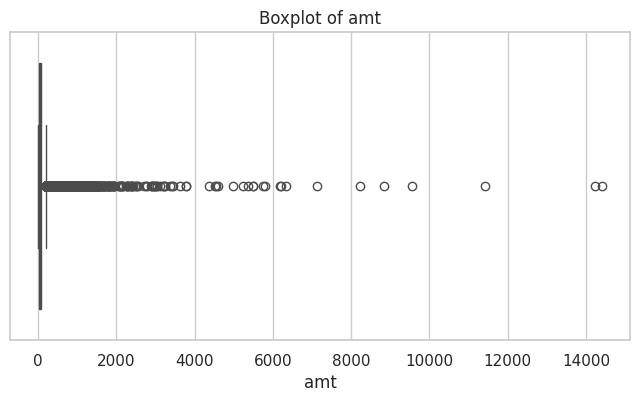

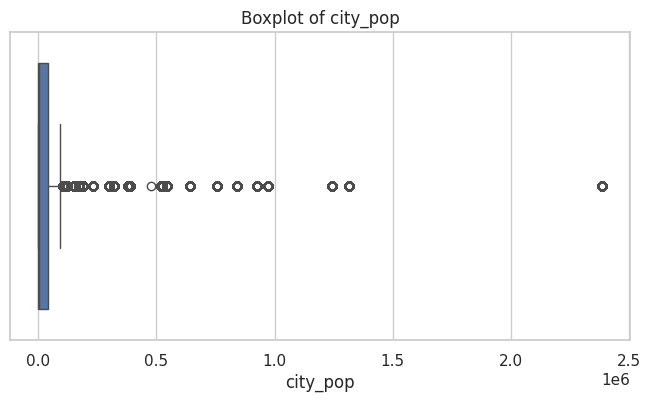

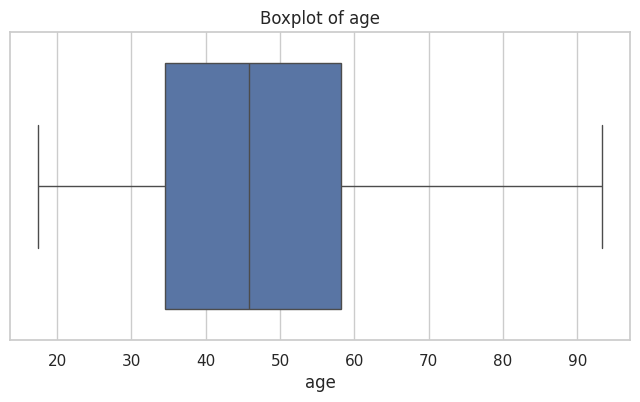

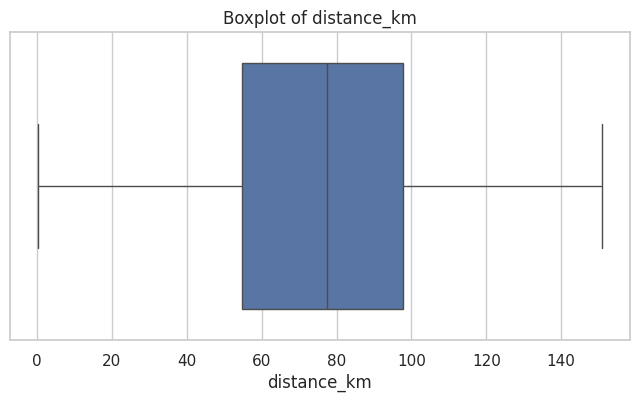

In [22]:
# ============================================
# 19. BOXPLOTS FOR ANOMALY DETECTION
# ============================================

for col in distribution_cols:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

In [23]:
# ============================================
# 20. IQR ANOMALY DETECTION
# ============================================

def detect_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return (
        Q1,
        Q3,
        lower_bound,
        upper_bound,
        outliers
    )


anomaly_results = []

for col in distribution_cols:

    Q1, Q3, lower, upper, outliers = (
        detect_outliers(df, col)
    )

    anomaly_results.append({
        'Feature': col,
        'Q1': Q1,
        'Q3': Q3,
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier %': (
            len(outliers) / len(df) * 100
        ),
        'Fraud Rate Among Outliers (%)':
            outliers['is_fraud'].mean() * 100
            if len(outliers) > 0 else np.nan
    })

anomaly_table = pd.DataFrame(
    anomaly_results
)

display(anomaly_table)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier %,Fraud Rate Among Outliers (%)
0,amt,9.570,82.735,-100.177,192.482,4543,5.149,2.399
1,city_pop,493.000,42384.000,-62343.500,105220.500,14328,16.238,0.223
2,age,34.478,58.260,-1.196,93.934,0,0.000,NaN
3,distance_km,54.705,97.776,-9.902,162.383,0,0.000,NaN


In [24]:
# ============================================
# 21. HIGH TRANSACTION AMOUNT ANOMALIES
# ============================================

Q1 = df['amt'].quantile(0.25)
Q3 = df['amt'].quantile(0.75)

IQR = Q3 - Q1

upper_amount_limit = Q3 + 1.5 * IQR

amount_outliers = df[
    df['amt'] > upper_amount_limit
]

print(
    "Upper IQR limit:",
    round(upper_amount_limit, 2)
)

print(
    "Number of high-amount anomalies:",
    len(amount_outliers)
)

print(
    "Percentage of transactions:",
    round(
        len(amount_outliers) / len(df) * 100,
        3
    ),
    "%"
)

print(
    "Fraud rate among high-amount anomalies:",
    round(
        amount_outliers['is_fraud'].mean() * 100,
        3
    ),
    "%"
)

print(
    "Overall fraud rate:",
    round(
        df['is_fraud'].mean() * 100,
        3
    ),
    "%"
)

Upper IQR limit: 192.48
Number of high-amount anomalies: 4543
Percentage of transactions: 5.149 %
Fraud rate among high-amount anomalies: 2.399 %
Overall fraud rate: 0.17 %


# 22. Fraud Rate by Transaction Category

Transaction categories are compared to determine whether fraud is
concentrated in particular types of transactions.

In [25]:
# ============================================
# 22. FRAUD RATE BY CATEGORY
# ============================================

category_analysis = (
    df.groupby('category')['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

category_analysis['Fraud_Rate_%'] = (
    category_analysis['Fraud_Rate'] * 100
)

category_analysis = category_analysis.sort_values(
    'Fraud_Rate_%',
    ascending=False
)

display(category_analysis)

,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
category,,,,
shopping_net,6881,34,0.005,0.494
grocery_pos,8492,31,0.004,0.365
misc_net,4456,16,0.004,0.359
shopping_pos,7844,15,0.002,0.191
gas_transport,9085,14,0.002,0.154
travel,2693,4,0.001,0.149
misc_pos,5176,7,0.001,0.135
grocery_net,3016,3,0.001,0.099
entertainment,6251,6,0.001,0.096


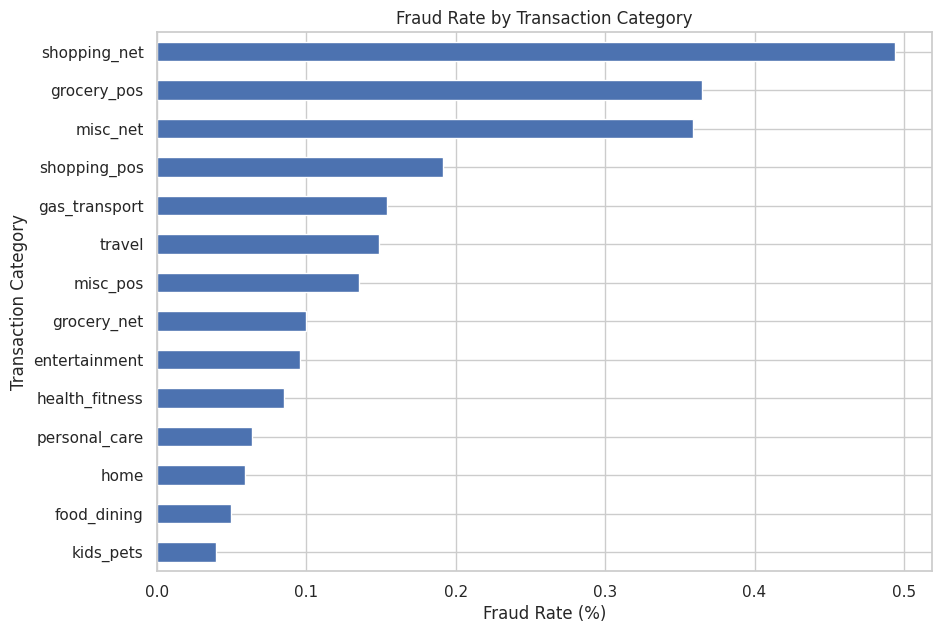

In [26]:
# ============================================
# 23. CATEGORY FRAUD RATE PLOT
# ============================================

plt.figure(figsize=(10, 7))

category_analysis[
    'Fraud_Rate_%'
].sort_values().plot(
    kind='barh'
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")

plt.show()

In [27]:
# ============================================
# 24. FRAUD RATE BY HOUR
# ============================================

hour_analysis = (
    df.groupby('hour')['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

hour_analysis['Fraud_Rate_%'] = (
    hour_analysis['Fraud_Rate'] * 100
)

display(hour_analysis)

,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
hour,,,,
0,2880,15,0.005,0.521
1,2928,13,0.004,0.444
2,2812,14,0.005,0.498
3,2915,11,0.004,0.377
4,2841,0,0.000,0.000
5,2938,1,0.000,0.034
6,2891,0,0.000,0.000
7,2888,0,0.000,0.000
8,2912,0,0.000,0.000


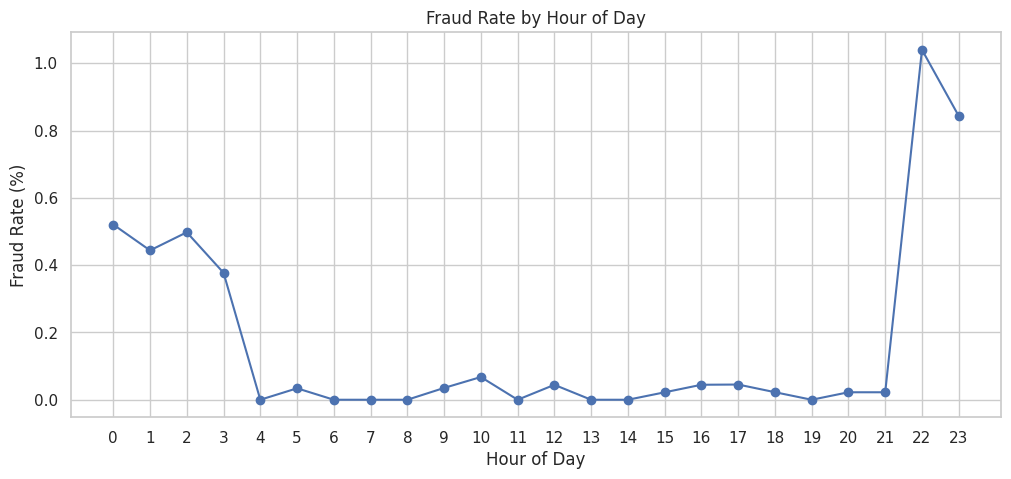

In [28]:
# ============================================
# 25. FRAUD RATE BY HOUR PLOT
# ============================================

plt.figure(figsize=(12, 5))

plt.plot(
    hour_analysis.index,
    hour_analysis['Fraud_Rate_%'],
    marker='o'
)

plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(range(24))

plt.show()

In [29]:
# ============================================
# 26. LATE-NIGHT TRANSACTION FLAG
# ============================================

df['late_night'] = df['hour'].isin(
    [22, 23, 0, 1, 2, 3]
)

print(
    df['late_night'].value_counts()
)

late_night
False    67893
True     20342
Name: count, dtype: int64


In [30]:
# ============================================
# 27. LATE-NIGHT VS NORMAL HOURS
# ============================================

late_night_analysis = (
    df.groupby('late_night')['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

late_night_analysis['Fraud_Rate_%'] = (
    late_night_analysis['Fraud_Rate'] * 100
)

display(late_night_analysis)

,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
late_night,,,,
False,67893,14,0.000,0.021
True,20342,136,0.007,0.669


In [31]:
# ============================================
# 28. FRAUD RATE BY DAY OF WEEK
# ============================================

day_analysis = (
    df.groupby('day_of_week')['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

day_analysis['Fraud_Rate_%'] = (
    day_analysis['Fraud_Rate'] * 100
)

display(day_analysis)

,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
day_of_week,,,,
0,17625,28,0.002,0.159
1,13006,21,0.002,0.161
2,8787,10,0.001,0.114
3,10134,20,0.002,0.197
4,10278,28,0.003,0.272
5,12442,24,0.002,0.193
6,15963,19,0.001,0.119


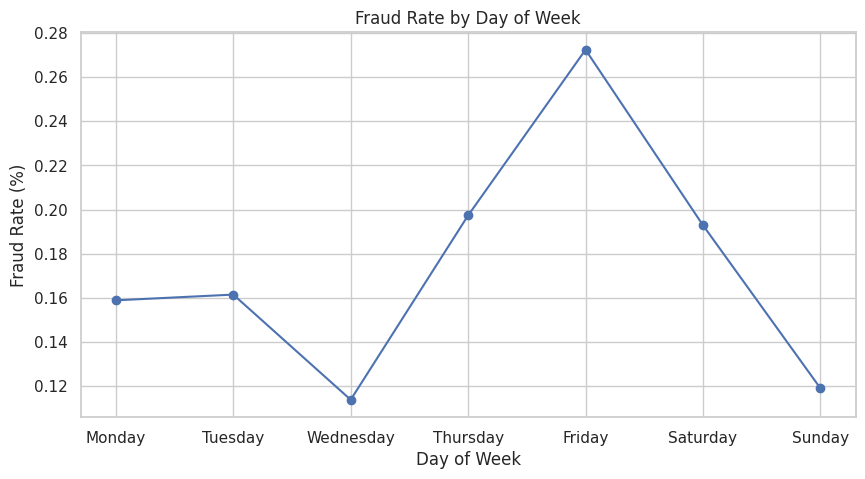

In [32]:
# ============================================
# 29. DAY-OF-WEEK FRAUD RATE PLOT
# ============================================

plt.figure(figsize=(10, 5))

plt.plot(
    day_analysis.index,
    day_analysis['Fraud_Rate_%'],
    marker='o'
)

plt.title("Fraud Rate by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")

plt.xticks(
    range(7),
    [
        'Monday',
        'Tuesday',
        'Wednesday',
        'Thursday',
        'Friday',
        'Saturday',
        'Sunday'
    ]
)

plt.show()

# 30. Correlation Analysis

Correlation analysis is used to identify linear relationships between
numerical features and the fraud target.

Correlation indicates association and does not establish causation.

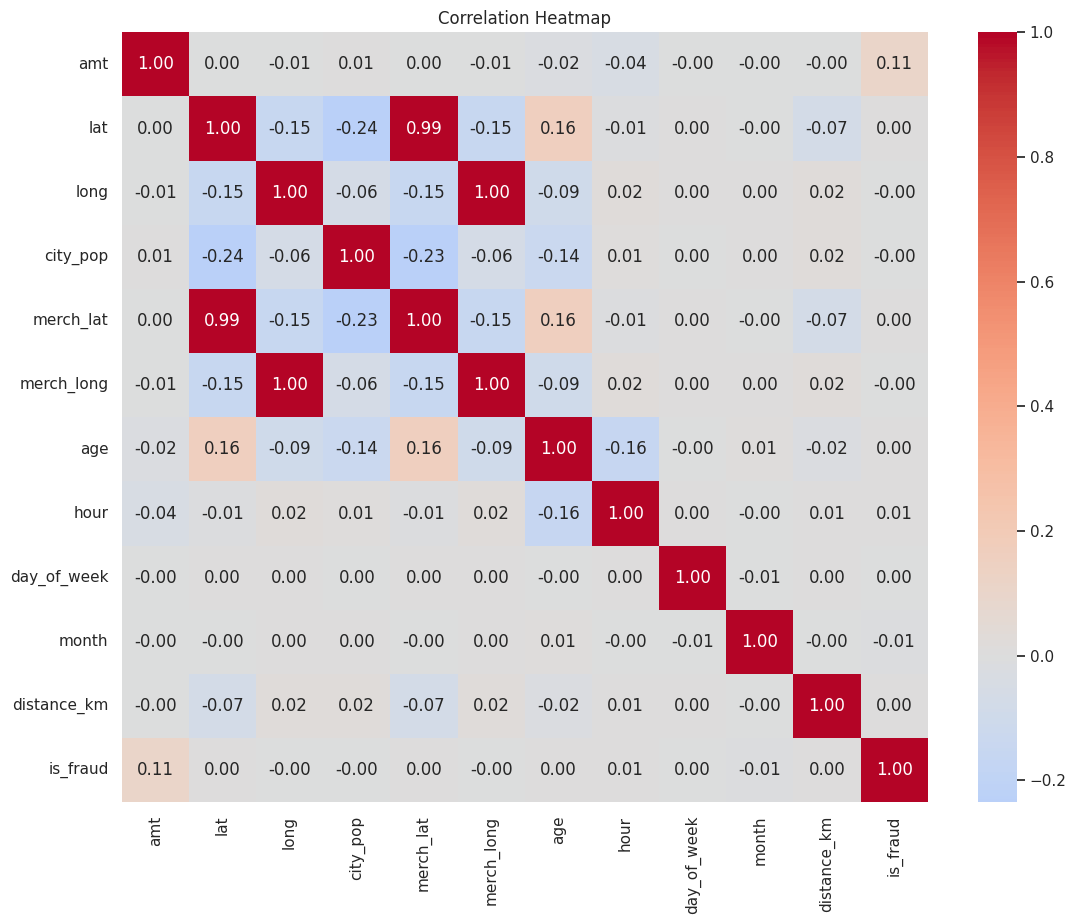

In [33]:
# ============================================
# 30. CORRELATION ANALYSIS
# ============================================

correlation_cols = [
    'amt',
    'lat',
    'long',
    'city_pop',
    'merch_lat',
    'merch_long',
    'age',
    'hour',
    'day_of_week',
    'month',
    'distance_km',
    'is_fraud'
]

correlation_matrix = df[
    correlation_cols
].corr()

plt.figure(figsize=(13, 10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
# ============================================
# 31. CORRELATION WITH FRAUD
# ============================================

fraud_correlations = (
    correlation_matrix['is_fraud']
    .sort_values(ascending=False)
)

display(fraud_correlations)

,is_fraud
is_fraud,1.000
amt,0.109
hour,0.009
distance_km,0.004
merch_lat,0.004
lat,0.004
age,0.004
day_of_week,0.001
city_pop,-0.000
merch_long,-0.001


In [35]:
# ============================================
# 32. ABSOLUTE CORRELATION RANKING
# ============================================

correlation_ranking = (
    correlation_matrix['is_fraud']
    .drop('is_fraud')
    .abs()
    .sort_values(ascending=False)
)

correlation_ranking_table = pd.DataFrame({
    'Feature': correlation_ranking.index,
    'Absolute Correlation': correlation_ranking.values
})

display(correlation_ranking_table)

,Feature,Absolute Correlation
0,amt,0.109
1,month,0.010
2,hour,0.009
3,distance_km,0.004
4,merch_lat,0.004
5,lat,0.004
6,age,0.004
7,long,0.001
8,merch_long,0.001
9,day_of_week,0.001


In [36]:
# ============================================
# 33. CATEGORY × LATE-NIGHT INTERACTION
# ============================================

interaction_analysis = (
    df.groupby(
        ['category', 'late_night']
    )['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

interaction_analysis['Fraud_Rate_%'] = (
    interaction_analysis['Fraud_Rate'] * 100
)

display(
    interaction_analysis
    .sort_values(
        'Fraud_Rate_%',
        ascending=False
    )
)

,,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
category,late_night,,,,
shopping_net,True,1679,32,0.019,1.906
misc_net,True,1389,16,0.012,1.152
grocery_pos,True,2846,26,0.009,0.914
shopping_pos,True,1773,14,0.008,0.790
travel,True,443,3,0.007,0.677
misc_pos,True,1341,7,0.005,0.522
gas_transport,True,2969,13,0.004,0.438
health_fitness,True,939,4,0.004,0.426
entertainment,True,1192,5,0.004,0.419


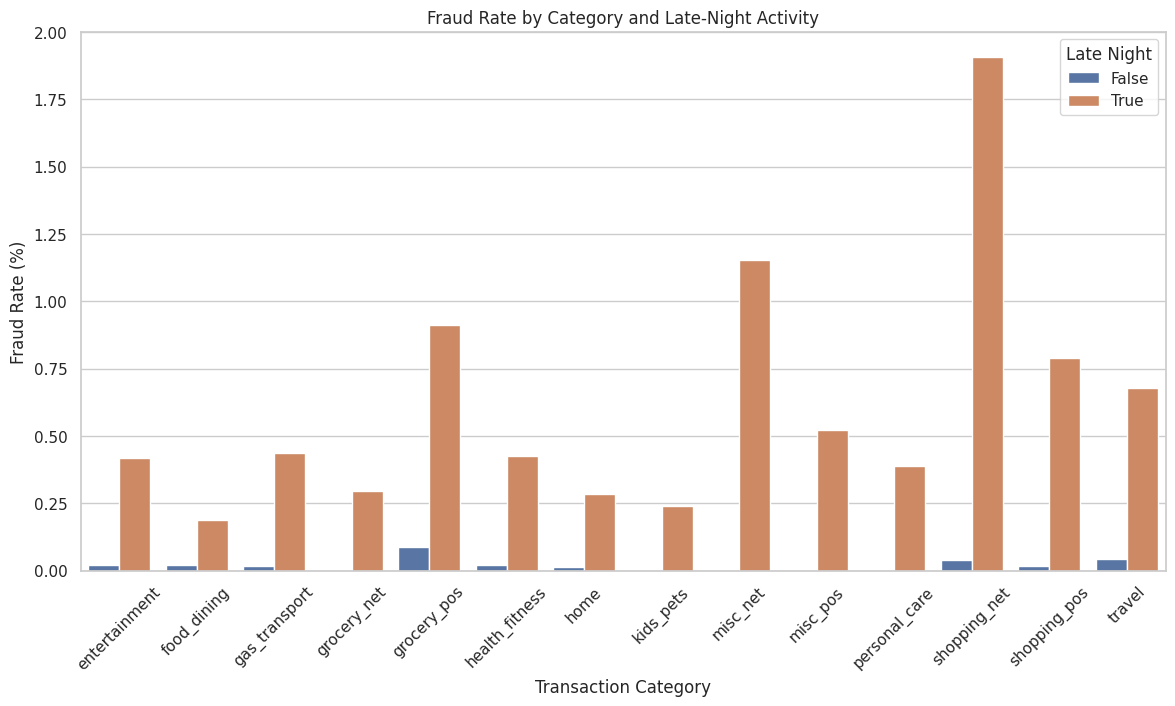

In [37]:
# ============================================
# 34. CATEGORY × LATE-NIGHT PLOT
# ============================================

interaction_plot = (
    df.groupby(
        ['category', 'late_night']
    )['is_fraud']
    .mean()
    .mul(100)
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=interaction_plot,
    x='category',
    y='is_fraud',
    hue='late_night'
)

plt.title(
    "Fraud Rate by Category and Late-Night Activity"
)

plt.xlabel("Transaction Category")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45)

plt.legend(
    title="Late Night"
)

plt.show()

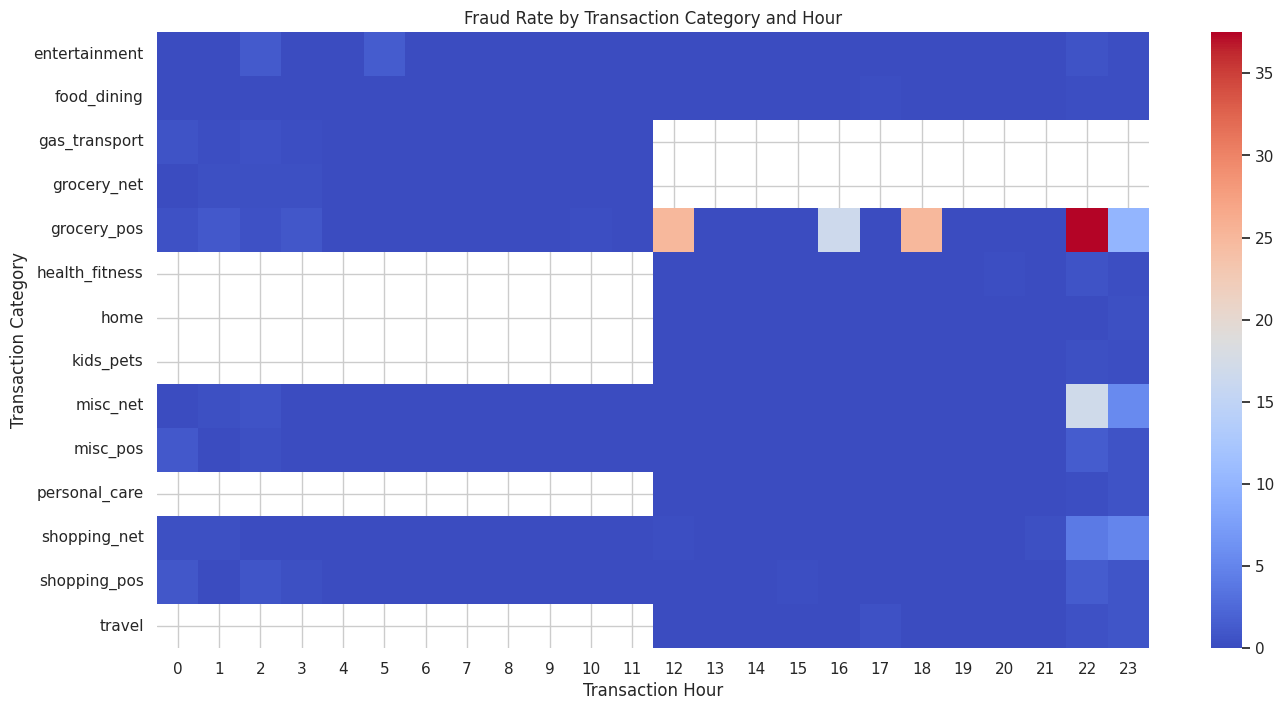

In [38]:
# ============================================
# 35. CATEGORY × HOUR INTERACTION
# ============================================

category_hour = (
    df.groupby(
        ['category', 'hour']
    )['is_fraud']
    .mean()
    .mul(100)
    .unstack()
)

plt.figure(figsize=(16, 8))

sns.heatmap(
    category_hour,
    annot=False,
    cmap='coolwarm'
)

plt.title(
    "Fraud Rate by Transaction Category and Hour"
)

plt.xlabel("Transaction Hour")
plt.ylabel("Transaction Category")

plt.show()

In [39]:
# ============================================
# 36. TOP CATEGORY-HOUR COMBINATIONS
# ============================================

category_hour_stats = (
    df.groupby(
        ['category', 'hour']
    )['is_fraud']
    .agg(
        Transaction_Count='count',
        Fraud_Count='sum',
        Fraud_Rate='mean'
    )
)

category_hour_stats['Fraud_Rate_%'] = (
    category_hour_stats['Fraud_Rate'] * 100
)

category_hour_filtered = (
    category_hour_stats[
        category_hour_stats['Transaction_Count'] >= 500
    ]
)

display(
    category_hour_filtered
    .sort_values(
        'Fraud_Rate_%',
        ascending=False
    )
    .head(15)
)

Transaction_Count  Fraud_Count  Fraud_Rate  Fraud_Rate_%
category      hour                                                          
grocery_pos   1                   729            8       0.011         1.097
              3                   730            7       0.010         0.959
gas_transport 0                   734            5       0.007         0.681
grocery_pos   0                   697            4       0.006         0.574
gas_transport 2                   714            4       0.006         0.560
grocery_pos   2                   672            3       0.004         0.446
home          23                  716            3       0.004         0.419
kids_pets     22                  636            2       0.003         0.314
grocery_pos   10                  734            2       0.003         0.272
gas_transport 1                   758            2       0.003         0.264
              3                   763            2       0.003         0.262
personal_care 22                  542            1       0.002         0.185
kids_pets     23                  617            1       0.002         0.162
home          22                  698            1       0.001         0.143
              16                  724            1       0.001         0.138

In [40]:
# ============================================
# 37. KEY FINDINGS
# ============================================

overall_fraud_rate = (
    df['is_fraud'].mean() * 100
)

late_night_fraud_rate = (
    df.loc[
        df['late_night'],
        'is_fraud'
    ].mean() * 100
)

normal_hour_fraud_rate = (
    df.loc[
        ~df['late_night'],
        'is_fraud'
    ].mean() * 100
)

top_category = (
    category_analysis.index[0]
)

top_category_rate = (
    category_analysis.iloc[0]['Fraud_Rate_%']
)

amount_anomaly_fraud_rate = (
    amount_outliers['is_fraud'].mean() * 100
)

strongest_feature = (
    correlation_ranking.index[0]
)

strongest_correlation = (
    correlation_matrix.loc[
        strongest_feature,
        'is_fraud'
    ]
)

print("=" * 60)
print("KEY DATA ANALYST FINDINGS")
print("=" * 60)

print(
    f"\nOverall fraud rate: "
    f"{overall_fraud_rate:.3f}%"
)

print(
    f"\nLate-night fraud rate: "
    f"{late_night_fraud_rate:.3f}%"
)

print(
    f"Normal-hour fraud rate: "
    f"{normal_hour_fraud_rate:.3f}%"
)

print(
    f"\nHighest fraud-rate category: "
    f"{top_category}"
)

print(
    f"Category fraud rate: "
    f"{top_category_rate:.3f}%"
)

print(
    f"\nHigh-amount anomaly fraud rate: "
    f"{amount_anomaly_fraud_rate:.3f}%"
)

print(
    f"\nStrongest correlation with fraud: "
    f"{strongest_feature}"
)

print(
    f"Correlation: "
    f"{strongest_correlation:.3f}"
)

KEY DATA ANALYST FINDINGS

Overall fraud rate: 0.170%

Late-night fraud rate: 0.669%
Normal-hour fraud rate: 0.021%

Highest fraud-rate category: shopping_net
Category fraud rate: 0.494%

High-amount anomaly fraud rate: 2.399%

Strongest correlation with fraud: amt
Correlation: 0.109


# 38. Top 3 Actionable Data Insights

### Insight 1 — Transaction Amount

Transaction amount is highly positively skewed, and it has the strongest
linear correlation with the fraud target among the numerical features
analyzed.

High-value transactions identified through IQR-based anomaly detection also
show a higher observed fraud rate than the overall dataset.

**Action:** The ML team should retain transaction amount as an important
feature and investigate appropriate preprocessing and its predictive value.

---

### Insight 2 — Late-Night Transactions

Late-night transactions show a higher observed fraud rate than transactions
during other hours.

This indicates that transaction timing may provide useful information for
fraud detection.

**Action:** The ML team should consider transaction hour and a late-night
indicator as candidate features.

---

### Insight 3 — Category × Time Interaction

Fraud rates vary across transaction categories and transaction times.

The combination of transaction category and late-night activity reveals
stronger fraud patterns than considering the two variables independently.

For example, shopping-net transactions during late-night hours show a
higher observed fraud rate than the overall dataset.

**Action:** The ML team should investigate interaction effects between
transaction category and transaction time.

# 39. Correlation Interpretation

The correlation analysis shows that transaction amount (`amt`) has the
strongest positive linear correlation with the fraud target among the
numerical variables analyzed.

Other numerical features have relatively weak linear correlations with fraud.

However, weak correlation does not necessarily mean that a feature has no
predictive value. Non-linear relationships and interactions may still be
useful to machine learning models.

Correlation represents association and should not be interpreted as proof
of causation.

# 40. Feature Interaction Interpretation

The category × late-night analysis shows that fraud rates differ depending
on the combination of transaction category and transaction timing.

This indicates that examining features together can reveal patterns that may
not be as clear when each feature is analyzed independently.

The interaction between transaction category and transaction time should
therefore be investigated by the Machine Learning team during feature
selection and model development.

# 41. Class Distribution Impact

The dataset contains a very small proportion of fraudulent transactions
compared with non-fraudulent transactions.

This class imbalance is important because a model could achieve high overall
accuracy by predicting the majority class while failing to identify many
fraudulent transactions.

Therefore, the Machine Learning team should consider fraud-focused metrics
such as precision, recall, F1-score and the confusion matrix when evaluating
the model.

# 42. Conclusion

The exploratory data analysis identified several important patterns in the
credit card transaction dataset.

The dataset is highly imbalanced, with fraudulent transactions representing
only a small proportion of all transactions. Transaction amount is highly
right-skewed and has the strongest linear correlation with the fraud target
among the numerical features analyzed.

The analysis also identified differences in fraud rates across transaction
categories and transaction times. Late-night transactions show a higher
observed fraud rate, and the interaction between transaction category and
late-night activity reveals additional patterns.

Potential anomalies in transaction amount were also investigated. These
observations should not automatically be removed because unusual values may
contain useful information for fraud detection.

These findings provide useful information for the Machine Learning team when
selecting features, investigating interactions and handling the highly
imbalanced fraud classification problem.

In [41]:
# ============================================
# 43. FINAL DATA ANALYST CHECK
# ============================================

print("=" * 65)
print("PAYSHIELD DATA ANALYST WORK COMPLETED")
print("=" * 65)

print("\nDataset Shape:")
print(df.shape)

print("\nFraud Distribution:")
display(class_distribution)

print("\nSkewness:")
display(skewness_table)

print("\nAnomaly Analysis:")
display(anomaly_table)

print("\nCategory Analysis:")
display(
    category_analysis[
        [
            'Transaction_Count',
            'Fraud_Count',
            'Fraud_Rate_%'
        ]
    ]
)

print("\nStrongest Correlations:")
display(
    correlation_ranking_table.head(5)
)

print("\nLate-Night Analysis:")
display(late_night_analysis)

print("\nTop Category-Hour Combinations:")
display(
    category_hour_filtered
    .sort_values(
        'Fraud_Rate_%',
        ascending=False
    )
    .head(10)
)

print("\nAll Data Analyst tasks completed.")

PAYSHIELD DATA ANALYST WORK COMPLETED

Dataset Shape:
(88235, 21)

Fraud Distribution:


,Transaction Count,Percentage
is_fraud,,
0,88085,99.830
1,150,0.170



Skewness:


,Feature,Skewness
0,amt,32.739
1,city_pop,3.683
2,age,0.702
3,distance_km,-0.223



Anomaly Analysis:


...


Late-Night Analysis:


,Transaction_Count,Fraud_Count,Fraud_Rate,Fraud_Rate_%
late_night,,,,
False,67893,14,0.000,0.021
True,20342,136,0.007,0.669



Top Category-Hour Combinations:


Transaction_Count  Fraud_Count  Fraud_Rate  Fraud_Rate_%
category      hour                                                          
grocery_pos   1                   729            8       0.011         1.097
              3                   730            7       0.010         0.959
gas_transport 0                   734            5       0.007         0.681
grocery_pos   0                   697            4       0.006         0.574
gas_transport 2                   714            4       0.006         0.560
grocery_pos   2                   672            3       0.004         0.446
home          23                  716            3       0.004         0.419
kids_pets     22                  636            2       0.003         0.314
grocery_pos   10                  734            2       0.003         0.272
gas_transport 1                   758            2       0.003         0.264


All Data Analyst tasks completed.
